In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Load the clean data
df = pd.read_parquet('../data/clean_data.parquet')
print(f"Loaded {len(df):,} rows")
print(f"Categories: {df['category'].nunique()}")
print(f"Date range: {df['order_date'].min().date()} to {df['order_date'].max().date()}")
df.head()

Matplotlib is building the font cache; this may take a moment.


Loaded 108,175 rows
Categories: 71
Date range: 2016-09-15 to 2018-08-29


,order_id,order_purchase_timestamp,price,freight_value,category,review_score,order_date,year_month
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,29.99,8.72,housewares,4.0,2017-10-02 10:56:33,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,118.70,22.76,perfumery,4.0,2018-07-24 20:41:37,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,159.90,19.22,auto,5.0,2018-08-08 08:38:49,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,45.00,27.20,pet_shop,5.0,2017-11-18 19:28:06,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,19.90,8.72,stationery,5.0,2018-02-13 21:18:39,2018-02


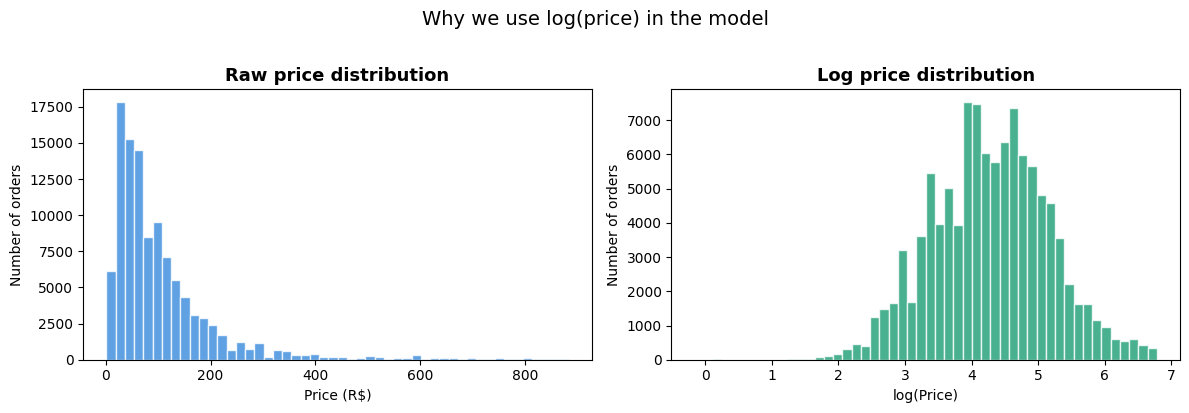

Chart saved to outputs folder


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left chart: raw price distribution
axes[0].hist(df['price'], bins=50, color='#378ADD', alpha=0.8, edgecolor='white')
axes[0].set_title('Raw price distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Price (R$)')
axes[0].set_ylabel('Number of orders')

# Right chart: log price distribution
axes[1].hist(np.log(df['price']), bins=50, color='#1D9E75', alpha=0.8, edgecolor='white')
axes[1].set_title('Log price distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(Price)')
axes[1].set_ylabel('Number of orders')

plt.suptitle('Why we use log(price) in the model', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/01_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to outputs folder")

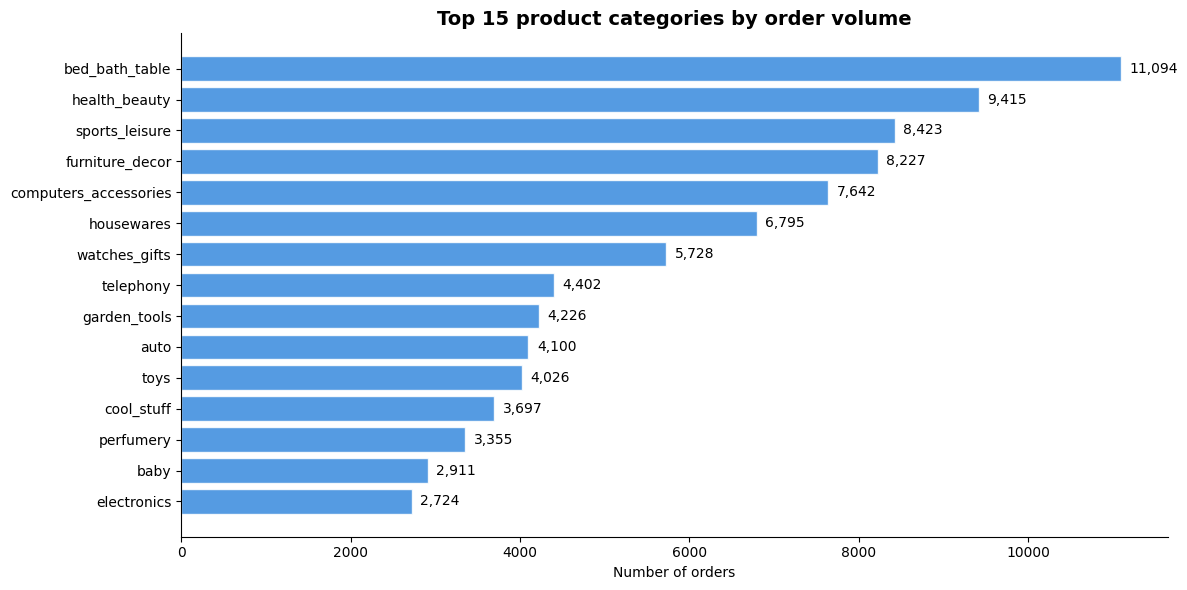

Chart saved


In [3]:
# Top 15 categories by number of orders
top_cats = (df.groupby('category')
    .size()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_cats.index[::-1], top_cats.values[::-1], 
               color='#378ADD', alpha=0.85, edgecolor='white')

# Add value labels on bars
for bar, val in zip(bars, top_cats.values[::-1]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)

ax.set_title('Top 15 product categories by order volume', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of orders')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/02_top_categories.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

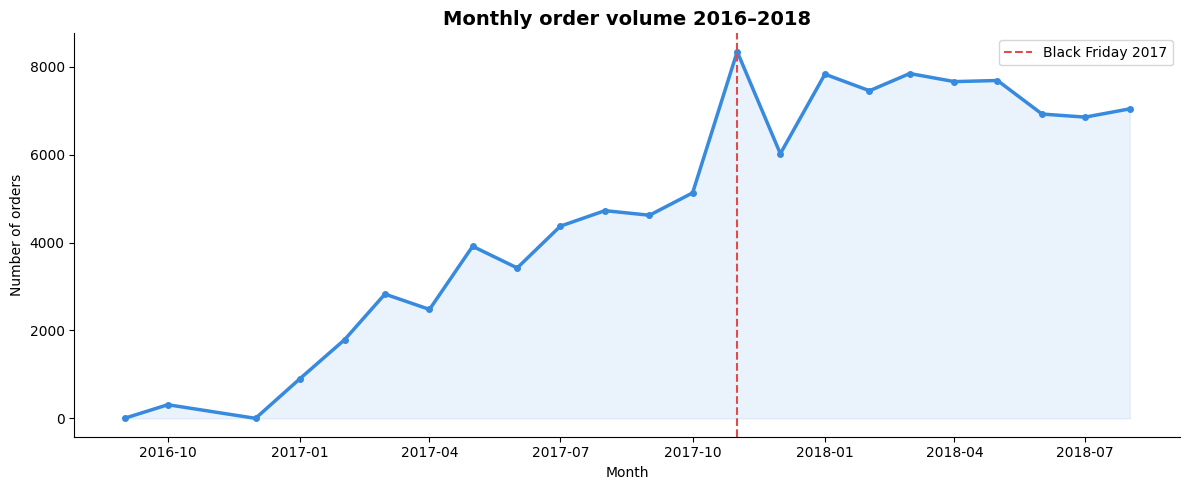

Chart saved


In [4]:
# Orders per month over time
monthly_orders = (df.groupby('year_month')
    .size()
    .reset_index(name='num_orders')
)
monthly_orders['year_month_dt'] = monthly_orders['year_month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_orders['year_month_dt'], monthly_orders['num_orders'], 
        color='#378ADD', linewidth=2.5, marker='o', markersize=4)
ax.fill_between(monthly_orders['year_month_dt'], monthly_orders['num_orders'], 
                alpha=0.1, color='#378ADD')

# Highlight Black Friday spike
ax.axvline(pd.Timestamp('2017-11-01'), color='#E24B4A', 
           linestyle='--', linewidth=1.5, label='Black Friday 2017')
ax.legend()

ax.set_title('Monthly order volume 2016–2018', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of orders')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/03_orders_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

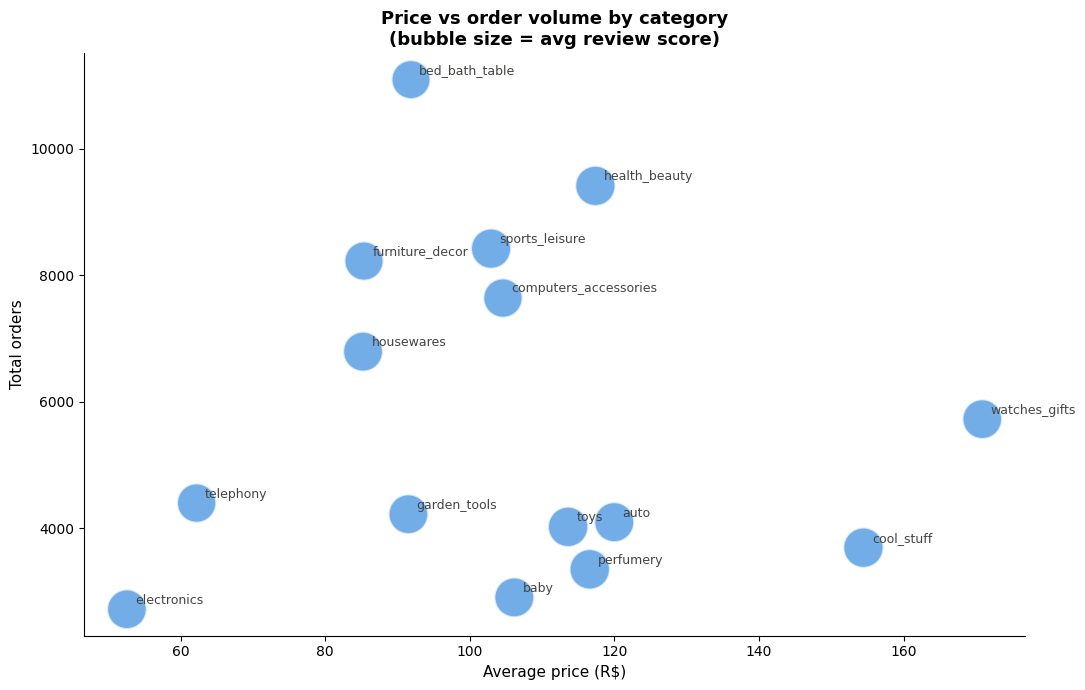

Chart saved


In [5]:
# Average price vs order volume per category (top 15)
top_15 = top_cats.index.tolist()
cat_summary = (df[df['category'].isin(top_15)]
    .groupby('category')
    .agg(
        avg_price=('price', 'mean'),
        num_orders=('order_id', 'count'),
        avg_review=('review_score', 'mean')
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 7))
scatter = ax.scatter(cat_summary['avg_price'], 
                     cat_summary['num_orders'],
                     s=cat_summary['avg_review'] * 200,
                     color='#378ADD', alpha=0.7, edgecolor='white', linewidth=1.5)

# Label each dot
for _, row in cat_summary.iterrows():
    ax.annotate(row['category'], 
                (row['avg_price'], row['num_orders']),
                xytext=(6, 4), textcoords='offset points', fontsize=9,
                color='#444441')

ax.set_title('Price vs order volume by category\n(bubble size = avg review score)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Average price (R$)', fontsize=11)
ax.set_ylabel('Total orders', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/04_price_vs_volume.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

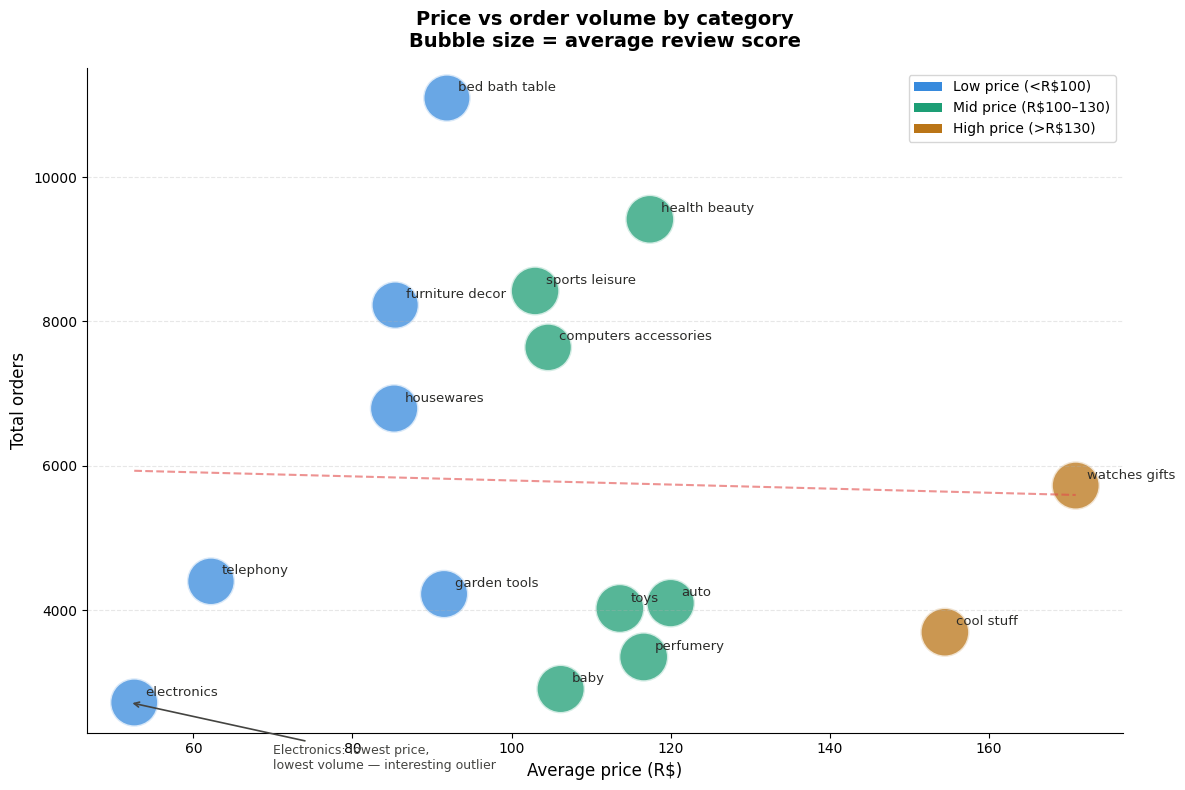

Chart saved


In [6]:
fig, ax = plt.subplots(figsize=(12, 8))

# Color by price range
colors = ['#378ADD' if p < 100 else '#1D9E75' if p < 130 else '#BA7517' 
          for p in cat_summary['avg_price']]

scatter = ax.scatter(cat_summary['avg_price'], 
                     cat_summary['num_orders'],
                     s=cat_summary['avg_review'] * 300,
                     c=colors, alpha=0.75, edgecolor='white', linewidth=2)

# Label each dot
for _, row in cat_summary.iterrows():
    ax.annotate(row['category'].replace('_', ' '), 
                (row['avg_price'], row['num_orders']),
                xytext=(8, 5), textcoords='offset points', fontsize=9.5,
                color='#2C2C2A', fontweight='500')

# Add a trend line
z = np.polyfit(cat_summary['avg_price'], cat_summary['num_orders'], 1)
p = np.poly1d(z)
x_line = np.linspace(cat_summary['avg_price'].min(), cat_summary['avg_price'].max(), 100)
ax.plot(x_line, p(x_line), '--', color='#E24B4A', linewidth=1.5, alpha=0.6, label='Trend line')

# Legend for colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#378ADD', label='Low price (<R$100)'),
    Patch(facecolor='#1D9E75', label='Mid price (R$100–130)'),
    Patch(facecolor='#BA7517', label='High price (>R$130)'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

ax.set_title('Price vs order volume by category\nBubble size = average review score',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Average price (R$)', fontsize=12)
ax.set_ylabel('Total orders', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add insight annotation
ax.annotate('Electronics: lowest price,\nlowest volume — interesting outlier',
            xy=(52, 2724), xytext=(70, 1800),
            arrowprops=dict(arrowstyle='->', color='#444441', lw=1.2),
            fontsize=9, color='#444441')

plt.tight_layout()
plt.savefig('../outputs/04_price_vs_volume.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

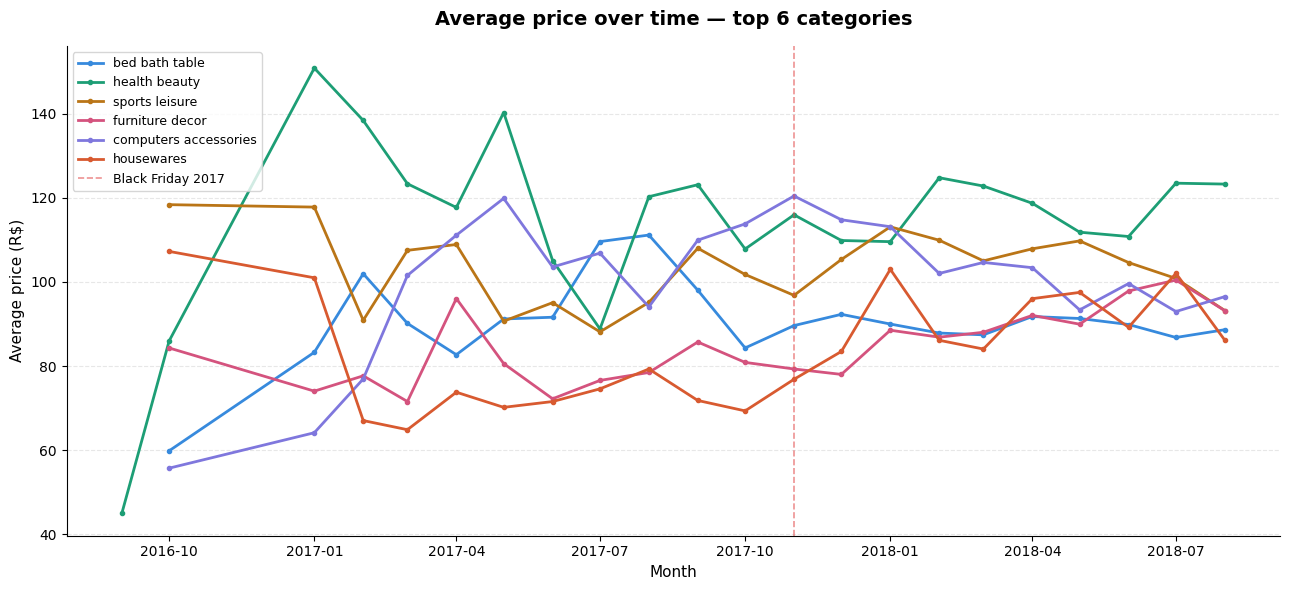

Chart saved


In [7]:
# Average price over time for top 6 categories
top_6 = top_cats.head(6).index.tolist()

monthly_price = (df[df['category'].isin(top_6)]
    .groupby(['category', 'year_month'])
    .agg(avg_price=('price', 'mean'))
    .reset_index()
)
monthly_price['year_month_dt'] = monthly_price['year_month'].dt.to_timestamp()

colors_6 = ['#378ADD', '#1D9E75', '#BA7517', '#D4537E', '#7F77DD', '#D85A30']

fig, ax = plt.subplots(figsize=(13, 6))

for i, cat in enumerate(top_6):
    data = monthly_price[monthly_price['category'] == cat]
    ax.plot(data['year_month_dt'], data['avg_price'],
            label=cat.replace('_', ' '),
            color=colors_6[i], linewidth=2, marker='o', markersize=3)

ax.axvline(pd.Timestamp('2017-11-01'), color='#E24B4A',
           linestyle='--', linewidth=1.2, alpha=0.6, label='Black Friday 2017')

ax.set_title('Average price over time — top 6 categories',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Average price (R$)', fontsize=11)
ax.legend(loc='upper left', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('../outputs/05_price_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")